# COSC-635: Lab 5

**Ben Miller**

[PLACEHOLDER_FOR_NOTEBOOK_LINK]

## Getting Started

Follow the instructions below to copy this notebook and to perform some initial setup.

1. Copy this notebook by selecting `File > Save a copy in Drive`.
2. A new window should open for the copied notebook. Move the new notebook to your course folder in Google Drive by selecting `File > Move` and then selecting the desired folder.
3. Update the name of the notebook by removing "Copy of" and replacing "Username" with your actual username.
4. Update the first cell in the notebook by specifying your course number (435 or 635) and by replacing "Student Name" with your actual name.
5. Do not edit the line that says `PLACEHOLDER_FOR_NOTEBOOK_LINK`. This will be used by the [notebook renderer](https://colab.research.google.com/drive/1CJTipys46ldZxJFwnt7XbdjQUfkmoXeU?usp=sharing) tool to insert a link to your Colab notebook.
6. Enable link sharing for your notebook.

## Preparing the Colab Environment

Run the cell below to install gymnasium and to download rltools to the virtual machine.

In [1]:
%%capture
!pip install swig
!pip install gymnasium[box2d]
!pip install "stable-baselines3[extra]"
!rm rltools -r
!git clone https://github.com/drbeane/rltools.git
!git clone https://github.com/drbeane/rl_models.git

The cell below includes the import statements that you will need for this assignmnet. No other import statements should be added anywhere in the notebook.

In [2]:
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import rltools.gym as gym
from rltools.utils import create_gif, evaluate
from rltools.utils import SB3Agent, sb3_evaluation_curves

from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import EvalCallback

import warnings
warnings.filterwarnings('ignore')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Note on Variable Names

You are free to select the variable names for the objects that you create in this notebook. But please make sure that the variable names you select in Part 1 are distinct from those used in Part 2. An exception to this rule can be made in instances where a particular variable will be used in a single cell, but no where else in the notebook.

# Part 1 - Cart Pole

In Part 1 of this assignment, you will train a DQN agent on the Cart Pole environment. We previously applied tabular methods such as Monte Carlo control and Q-Learning to the Cart Pole environment. Those techniques required us to discretize the environment states. The DQN algorithm, however, can be applied to environments with continuous state spaces.

**Your goal will be to train a model capable of consistenly keeping the pole upwrite for at least 1000 time steps.**

## 1.A - Create Environments

Use the cell below to create three instances of the Cart Pole environment, one for training, one for evaluation, and one for testing.

In each environment, set `max_angle=0.21`. Using the smaller angle range will make it easier for the agent to learn a good policy. Do not forgot to set the `render_mode` for the test environment.

Reset the training and evaluation environments, setting `seed=1` in both cases. Capture the output of the `reset()` method in variables so that aren't displayed in the notebook.


In [3]:
base_env = gym.make("CartPole-v1", render_mode='rgb_array', max_angle=0.21)
eval_env = gym.make("CartPole-v1", render_mode='rgb_array', max_angle=0.21)
test_env = gym.make("CartPole-v1", render_mode='rgb_array', max_angle=0.21)

base_state, base_info = base_env.reset(seed=1)
eval_state, eval_info = eval_env.reset(seed=1)
test_state, test_info = test_env.reset(seed=1)

## 1.B - Create Evaluation Callback

In the cell below, create an `EvalCallback` object using the evaluation environment. Set the calback to run the evalation every 1000 time steps, using 20 episodes for each evaluation. Set `warn=False` and `deterministic=True`.

**Note: You will create two evaluation callbacks in this notebook. You should use different names for the directories associated with these callbacks.**

In [4]:
if os.path.exists('evaluation_cartpole/') : shutil.rmtree('evaluation_cartpole/')

eval_callback = EvalCallback(
    eval_env,
    n_eval_episodes=20,
    eval_freq=1000,
    best_model_save_path='evaluation_cartpole/',
    log_path='evaluation_cartpole/',
    warn=False,
    deterministic=True
)

## 1.C - Build and Train Model

Create an instance of `DQN`. Guidance for the parameter selection is provided in the list below. If a parameter is not mentioned, then use the default values for that parameter.

* `policy` - Set this to `"MLpPolicy"`.
* `env` - Set this to the environment you created for training.
* `learning_rate` - Experiment with values within the range  `[0.001, 0.1]`.  
* `gamma` - Experiment with values within the range `[0.9, 1.0]`.
* `exploration_fraction` - Experiment with values within the range `[0.1, 0.3]`.
* `exploration_final_eps` - Experiment with values within the range `[0.01, 0.1]`.
* `target_update_interval` - Set to 10.
* `train_freq` - Set to 256.
* `gradient_steps` - Set to -1.
* `batch_size` - Set to 64.
* `buffer_size` - Set to 100,000.
* `learning_starts` - Set to 1000.
* `policy_kwargs` - Use this to specify that the network should have 2 hidden layers, each with 256 nodes.
* `seed` - Set to 1.

Train the model for somewhere between 30,000 and 50,000 timesteps, using the callback created in Step 1.B. Set `progress_bar=False`.

**Recall that your goal is to train an agent that can consistently keep the pole balanced upright for at least 1000 time steps.** This goal is achievable with 30,000 timesteps, with the right parameters.



In [5]:
%%time

cartpole_model = DQN(
    policy='MlpPolicy',
    env=base_env,
    learning_rate=0.01,
    gamma=0.9,
    exploration_fraction=0.1,
    exploration_final_eps=0.01,
    target_update_interval=10,
    train_freq=256,
    gradient_steps=-1,
    batch_size=64,
    buffer_size=100000,
    learning_starts=1000,
    policy_kwargs=dict(net_arch=[256, 256]),
    seed=1,
)

model = cartpole_model.learn(total_timesteps=30_000, progress_bar=False, callback=eval_callback)

Eval num_timesteps=1000, episode_reward=8.25 +/- 0.62
Episode length: 9.25 +/- 0.62
New best mean reward!
Eval num_timesteps=2000, episode_reward=111.60 +/- 12.06
Episode length: 112.60 +/- 12.06
New best mean reward!
Eval num_timesteps=3000, episode_reward=121.70 +/- 3.77
Episode length: 122.70 +/- 3.77
New best mean reward!
Eval num_timesteps=4000, episode_reward=80.75 +/- 2.62
Episode length: 81.75 +/- 2.62
Eval num_timesteps=5000, episode_reward=234.45 +/- 62.14
Episode length: 235.45 +/- 62.14
New best mean reward!
Eval num_timesteps=6000, episode_reward=94.75 +/- 2.74
Episode length: 95.75 +/- 2.74
Eval num_timesteps=7000, episode_reward=1000.00 +/- 0.00
Episode length: 1000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=8000, episode_reward=90.30 +/- 3.13
Episode length: 91.30 +/- 3.13
Eval num_timesteps=9000, episode_reward=88.40 +/- 1.77
Episode length: 89.40 +/- 1.77
Eval num_timesteps=10000, episode_reward=90.85 +/- 2.80
Episode length: 91.85 +/- 2.80
Eval num_timestep

## 1.D - Plot the Evaluation Results

Used the `sb3_evaluation_curves()` function to generate plots illustrating the progression of the scores for the evaluation environment during training.

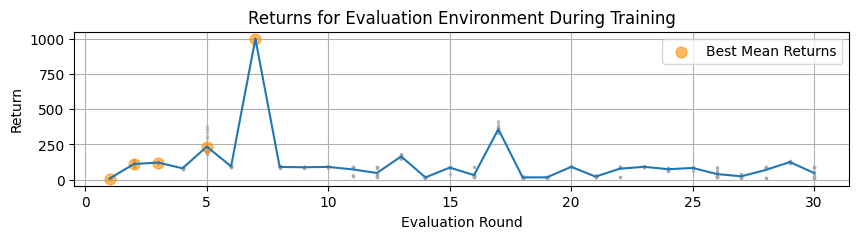

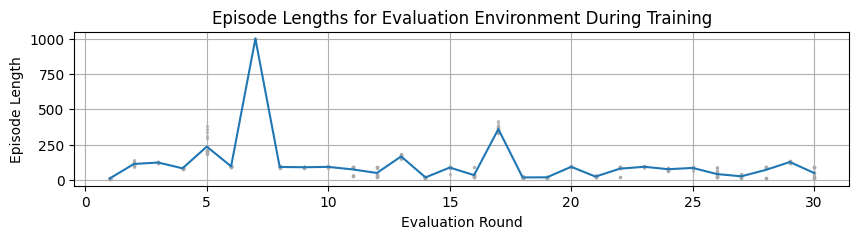

In [6]:
sb3_evaluation_curves('evaluation_cartpole/')

## 1.E - Load and Evaluate the Best Model

Use the cell below to load the best model encountered during training, passing the test environment to the `env` parameter for the `DQN.load()` method. Create an instance of `SB3Agent` using this model. Then use the `evaluate()` function to score the model, setting `gamma=1.0`, `episodes=100`, and `max_steps=1000`.

**Your model should have a mean return of 1000.0.** If it does not, then you will need to adjust the parameters in part 1.C and train the model again. You should re-run the cells in 1.A and 1.B before re-running 1.C.

In [7]:
best_model = DQN.load('evaluation_cartpole/best_model.zip', env=test_env)
dqn_agent = SB3Agent(best_model)
results = evaluate(test_env, dqn_agent, gamma=1.0, episodes=100, max_steps=1000)

Mean Return:    1000.0
StdDev Return:  0.0
Mean Length:    1000.0
StdDev Length:  0.0


## 1.F - Display Episode

Use the `create_gif()` function to display an episode guided by the trained DQN agent. Set `seed=1` and `max_steps=1000`.

1000 steps completed.
Cumulative reward: 1000.0


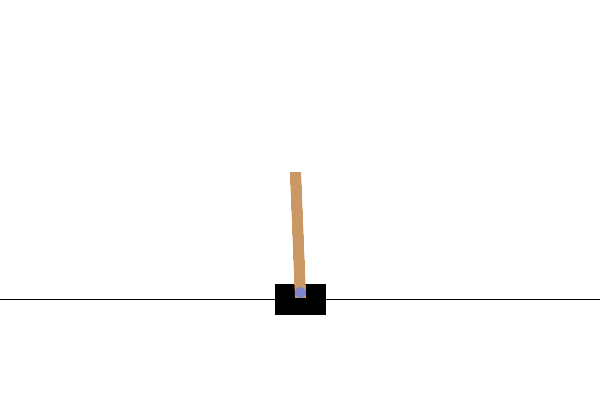

In [8]:
create_gif(test_env, dqn_agent, max_steps=1000, seed=1, folder='gifs', filename='dqn_agent')

# Part 2 - Lunar Lander

In Part 2 of this assignment, you will train a DQN agent on the Lunar Lander environment. Training a DQN agent to do well in this environment requires many episodes of training and can be a time-consuming process. We wil introduce algorithms and tools that will allow to more quickly train agents for this environments in later weeks.

This week, we will take the opportunity to get experience with loading and evaluating partially trained models. We will load several models that are at various stages in the training process and will observe how their behavior evolves over time. We will then perform some additional training on one such model.

The pre-trained models that you will be working with in this notebook can be found in the `rl_models/lunar_lander/` directory on the virtual machine hosting this notebook.

A notebook demonstrating a fully-trained version of the model can be found here: [DQN Demo - Lunar Lander](https://colab.research.google.com/drive/16C12ZYRScbG9WvkQIgxlpjrJNjjOKVJe?usp=sharing). You can view this notebook to see the paramaters that were used to train the model.

## ⚠️ Displaying Lunar Lander Gifs  ⚠️

The gifs we create for the Lunar Lander environment in Part 2 will have a larger filesize than previous gifs created in this course. Google Colab will not include gifs above a certain filesize in HTML renders. In order to avoid gifs being exlcuded from your HTML renders, we will set `num_colors=16` when calling `create_gif`. This reduces the number of colors available in the gifs, thus reducing their file size.

Please read this message carefully, and check your HTML renders before submitting them to Canvas. **No credit will be given for tasks whose output does not appear in the HTML render.**



## 2.A - Create Environment

Use the cell below to create an instance of the lunar lander enviornment. This agent will be used for testing pretrained models.

In [9]:
ll_base_env = gym.make("LunarLander-v3", render_mode='rgb_array')

## 2.B - Load and Evaluate Untrained Model

We will start by analyzing a DQN agent that has not been trained. Perform the following steps in the cell below:
1. Use `DQN.load()` to load the model named `model_00000.zip`.
2. Use the loaded model to create an instance of `SB3Agent`.
3. Use the `evaluate()` function to evaluate the agent. Use `gamma=1.0`, `episodes=20`, `max_steps=1000`, and `seed=1`.
4. Create a gif demonstrating the agent's behavior. Use `max_steps=1000` and `seed=0`.

**Note: Please pay careful attention to the the instructions regarding seed values.**

In [10]:
untrained_model = DQN.load("rl_models/lunar_lander/model_00000.zip")
untrained_dqn_agent = SB3Agent(untrained_model)
results = evaluate(ll_base_env, untrained_dqn_agent, gamma=1.0, episodes=20, max_steps=1000, seed=0)

Mean Return:    -573.7962
StdDev Return:  140.0892
Mean Length:    74.55
StdDev Length:  12.7768


## 2.C - Load and Evaluate Partially Trained Model (5K)

We will now look at a model that has been trained for 5000 time steps. Repeat the steps from 2.B using the model stored in the file `model_05000.zip`. You should observe that the agentmakes some effort to avoid crashing, but does still eventually crash.



In [11]:
partial_5k_model = DQN.load("rl_models/lunar_lander/model_05000.zip")
partial_5k_dqn_agent = SB3Agent(partial_5k_model)
results = evaluate(ll_base_env, partial_5k_dqn_agent, gamma=1.0, episodes=20, max_steps=1000, seed=0)

Mean Return:    -169.5253
StdDev Return:  64.3881
Mean Length:    655.25
StdDev Length:  384.1812


## 2.D - Load and Evaluate Partially Trained Model (25K)

We will now look at a model that has been trained for 25,000 time steps. Repeat the steps from 2.B using the model stored in the file `model_25000.zip`. You should observe that the agent has learned to avoid crashing, but will not land.


In [12]:
partial_25k_model = DQN.load("rl_models/lunar_lander/model_25000.zip")
partial_25k_dqn_agent = SB3Agent(partial_25k_model)
results = evaluate(ll_base_env, partial_25k_dqn_agent, gamma=1.0, episodes=20, max_steps=1000, seed=0)

Mean Return:    -10.8748
StdDev Return:  70.7097
Mean Length:    956.95
StdDev Length:  107.6371


## 2.E - Load and Evaluate Partially Trained Model (80K)

We will now look at a model that has been trained for 80,000 time steps. Repeat the steps from 2.B using the model stored in the file `model_80000.zip`. You should observe that the agent has finally learned to land, but that it does so very slowly and cautiously.


In [13]:
partial_80k_model = DQN.load("rl_models/lunar_lander/model_80000.zip")
partial_80k_dqn_agent = SB3Agent(partial_80k_model)
results = evaluate(ll_base_env, partial_80k_dqn_agent, gamma=1.0, episodes=20, max_steps=1000, seed=0)

Mean Return:    7.8676
StdDev Return:  52.5095
Mean Length:    966.9
StdDev Length:  144.2796


## 2.F - Continued Training

We will now train the 80K model for another 20K timesteps. In addition to loading the model, we will also reload the replay buffer containing the experiences generated during the first 80K timesteps. Use the cell below to perform the following steps:
1. Create three new instances of the Lunar Lander environment: One for training, one for evaluation, and one for testing.
2. Reset the training and evaluation environments, setting `seed=1` in both cases.
3. Create an `EvalCallback` object using the evaluation environment. Set the calback to run the evalation every 2000 time steps, using 20 episodes for each evaluation. Set `warn=False`  and `deterministic=True`.
    * **When specifying a directory for the evaluation callback, you should use a different name from what was used in Part 1.**
4. Reload `model_80000.zip` into a new DQN model. Use the training environment when loading the model.
5. Use the `load_replay_buffer()` to load the replay buffer into the model. This is stored in the file `buffer_80000.pkl`.
6. Train the model for an additional 20,000 time steps, using the callback created. Set `progress_bar=False`.

This will likely take 5-10 minutes to run.

In [14]:
ll_base_env = gym.make("LunarLander-v3", render_mode='rgb_array')
ll_eval_env = gym.make("LunarLander-v3", render_mode='rgb_array')
ll_test_env = gym.make("LunarLander-v3", render_mode='rgb_array')

ll_base_state, ll_base_info = ll_base_env.reset(seed=1)
ll_eval_state, ll_eval_info = ll_eval_env.reset(seed=1)
ll_test_state, ll_test_info = ll_test_env.reset(seed=1)

if os.path.exists('ll_evaluation/') : shutil.rmtree('ll_evaluation/')
ll_eval_callback = EvalCallback(
    ll_eval_env,
    best_model_save_path="ll_evaluation/",
    log_path="ll_evaluation/",
    n_eval_episodes=20,
    eval_freq=2000,
    warn=False,
    deterministic=True
)

partial_80k_model = DQN.load("rl_models/lunar_lander/model_80000.zip", env=ll_base_env)
partial_80k_model.load_replay_buffer("rl_models/lunar_lander/buffer_80000.pkl")

model = partial_80k_model.learn(total_timesteps=20_000, progress_bar=False, callback=ll_eval_callback)



Eval num_timesteps=2000, episode_reward=-0.63 +/- 22.10
Episode length: 1000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=4000, episode_reward=26.39 +/- 97.43
Episode length: 854.55 +/- 274.79
New best mean reward!
Eval num_timesteps=6000, episode_reward=84.64 +/- 102.77
Episode length: 853.30 +/- 252.35
New best mean reward!
Eval num_timesteps=8000, episode_reward=197.95 +/- 87.02
Episode length: 469.75 +/- 287.11
New best mean reward!
Eval num_timesteps=10000, episode_reward=181.72 +/- 95.93
Episode length: 547.85 +/- 313.17
Eval num_timesteps=12000, episode_reward=136.03 +/- 173.79
Episode length: 368.65 +/- 260.80
Eval num_timesteps=14000, episode_reward=129.26 +/- 124.89
Episode length: 628.00 +/- 327.25
Eval num_timesteps=16000, episode_reward=106.61 +/- 140.93
Episode length: 567.45 +/- 342.44
Eval num_timesteps=18000, episode_reward=134.61 +/- 130.01
Episode length: 493.90 +/- 289.43
Eval num_timesteps=20000, episode_reward=171.99 +/- 191.14
Episode length: 368.80 +/- 1

## 2.G - Evaluating Final Model

Use the cell below to load the best model encountered during training, passing the test environment to the `env` parameter for the `DQN.load()` method. Create an instance of `SB3Agent` using this model. Then use the `evaluate()` function to score the model, setting `gamma=1.0`, `episodes=50`, and `max_steps=1000`.

If everything was done correctly, your agent should get a mean return of 179.5702.

In [15]:
best_model = DQN.load('ll_evaluation/best_model.zip', env=ll_test_env)
dqn_agent = SB3Agent(best_model)
results = evaluate(ll_test_env, dqn_agent, gamma=1.0, episodes=50, max_steps=1000)

Mean Return:    179.5702
StdDev Return:  101.7811
Mean Length:    540.28
StdDev Length:  313.0068


## 2.H - Display Episode

Use the `create_gif()` function to display an episode guided by the trained DQN agent. Set `seed=0` and `max_steps=1000`. You should observe the lander landing safeley between the flags in 844 time steps.

844 steps completed.
Cumulative reward: 193.1916


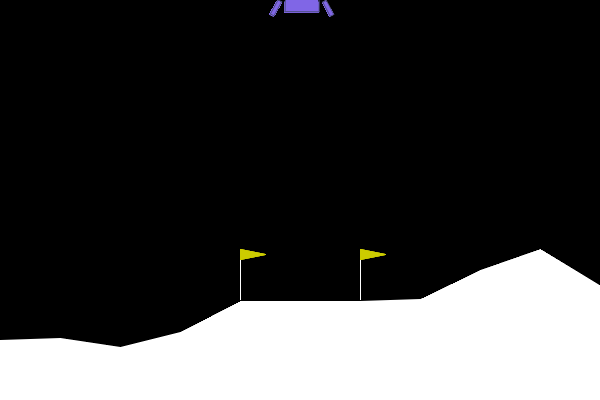

In [16]:
create_gif(ll_test_env, dqn_agent, num_colors=16, max_steps=1000, seed=0, folder='gifs', filename='ll_dqn_agent')

# Submission Instructions

1. Perform a Restart and Run All by clicking **Runtime > Restart session and run all**.
2. Copy the link to your notebook by clicking **Share > Copy Link**.
3. Paste the copied link into the `notebook_url` field in the [Notebook Renderer](https://colab.research.google.com/drive/1CJTipys46ldZxJFwnt7XbdjQUfkmoXeU?usp=sharing) tool and then execute the cell to render the notebook.
4. The Notebook Renderer will open up a save file dialog. Save the resulting HTML file yo your local machine.
5. Submit the HTML file to Canvas.
